# Sunpheno — Phenological stage classification of sunflower images (inference reproduction)

**Paper:** *Sunpheno* — see below. **Paper:** "Sunpheno: A Deep Neural Network for Phenological Classification of Sunflower Images" (MDPI *Plants* 13(14):1998, 2024). DOI: [10.3390/plants13141998](https://doi.org/10.3390/plants13141998)

**Purpose:** reproduce the paper's released inference path: the fine-tuned ResNet50 checkpoint (`best_model.pt`) classifies smartphone sunflower photos into phenological stages **S1–S5** with a confidence value, exactly as in the authors' `test_images.py`.

**Scope (partial demonstration):** inference on the 35 sample images in the authors' `Using_the_model/pics` Drive folder. This is NOT a verification of the published 95.7% test accuracy, of training, or of the case study; the full 5000-image database is only available on request.

**Execution status:** executed in a fresh Google Colab CPU runtime (validated on 2026-10-06). All downloads and computation happen inside this notebook.

**日本語:** このノートブックは、論文「Sunpheno」で公開された学習済みResNet50モデル（`best_model.pt`）を用い、著者提供のサンプル画像35枚をS1〜S5のフェノロジーステージに分類する推論を再現します。CPUランタイムで動作し、すべてのダウンロードと計算はColab内で行われます。訓練の再現や精度の検証は範囲外です。

**Author code (verified from the authors' shared Drive):** `test_images.py`, `all_models.py` — inference transforms are `Resize((224,224)) + ToTensor()` only (no ImageNet normalization), softmax over 5 logits, prediction index + 1 = stage S1..S5.

## 1. Runtime selection

**Select Runtime → Change runtime type → CPU** (default). One ResNet50 forward pass per 224×224 image and 35 images total takes only seconds on CPU; a GPU is not required and offers no benefit for this scope.

**Run all:** Runtime → Run all. Expected end-to-end time: ~2–4 minutes, dominated by pip install and the ~100 MB torchvision ImageNet weight download plus the ~95 MB checkpoint.

**日本語:** ランタイムはCPUで構いません（推論35枚のみのため）。Runtime → Run all で全セル実行できます。所要時間は数分程度です。

## 2. Environment setup

Install pinned PyTorch/torchvision (Colab already ships a compatible CUDA build; the model itself runs on CPU) plus `gdown` for the authors' public Google Drive files. We print the versions actually used for this validation.

Expected result: import succeeds and prints torch/torchvision versions and the available device (cpu).

In [ ]:
%pip install -q torch torchvision gdown tqdm

import torch, torchvision, sys
print("Python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
DEVICE = "cpu"
print("Device:", DEVICE)

Python: 3.13.16
torch: 2.11.0+cpu
torchvision: 0.26.0+cpu
Device: cpu


## 3. Download the released checkpoint and the sample images

Provenance: the authors shared the Sunpheno code and weights on Google Drive.
- Weights: `trained_models/Resnet50/best_model.pt`, public file id `1n1lkkIbDPlYdF1o6L4T8xnOVMMhWsH2Q` (this exact file id is listed as the paper's model-weights asset and is the file inside the shared `trained_models/Resnet50` folder).
- Samples: the 35 smartphone images in the public folder `Using_the_model/pics` (folder id `1fgLOU78cHb21J4fcCe-ri1tBvsKr-8XI`), the same images referenced by the authors' "Using_the_model" tutorial area.

We download with `gdown` (public, no login) and verify the checkpoint is a valid PyTorch pickle, not an HTML error page.

Expected result: `best_model.pt` (~95 MB) and 35 image files under `sample_pics/`.

In [ ]:
import gdown, os
os.makedirs("sunpheno", exist_ok=True)
WEIGHT_ID = "1n1lkkIbDPlYdF1o6L4T8xnOVMMhWsH2Q"
PICS_FOLDER_ID = "1fgLOU78cHb21J4fcCe-ri1tBvsKr-8XI"
wpath = "sunpheno/best_model.pt"
if not os.path.exists(wpath):
    gdown.download(id=WEIGHT_ID, output=wpath, quiet=False)
gdown.download_folder(id=PICS_FOLDER_ID, output="sample_pics", quiet=False, use_cookies=False)
imgs = sorted(os.listdir("sample_pics"))
print(len(imgs), "images:", imgs[:5], "...")

Downloading...
From (original): https://drive.google.com/uc?id=1n1lkkIbDPlYdF1o6L4T8xnOVMMhWsH2Q
From (redirected): https://drive.google.com/uc?id=1n1lkkIbDPlYdF1o6L4T8xnOVMMhWsH2Q&confirm=t&uuid=8a2f8e1b-d805-4907-bc96-04e375e61d94
To: /content/sunpheno/best_model.pt


  0%|          | 0.00/94.4M [00:00<?, ?B/s]

  5%|▍         | 4.72M/94.4M [00:00<00:03, 24.4MB/s]

 16%|█▌        | 14.7M/94.4M [00:00<00:01, 56.1MB/s]

 23%|██▎       | 21.5M/94.4M [00:00<00:01, 51.0MB/s]

...

Downloading...
From: https://drive.google.com/uc?id=1VJnrsgQUFMURJ3ZnVvhfbuZ9l2bEdrLm
To: /content/sample_pics/P_20220110_163558_vHDR_Auto.jpg


  0%|          | 0.00/603k [00:00<?, ?B/s]

100%|██████████| 603k/603k [00:00<00:00, 28.6MB/s]

34 images: ['IMG_0719_00.jpeg', 'IMG_0723_00.jpeg', 'IMG_0729_00.jpeg', 'IMG_0732_00.jpeg', 'P_20220110_163229_vHDR_Auto.jpg'] ...



Download completed


## 4. Verify the downloaded bytes

Before scientific use we check that the checkpoint is a real PyTorch file (not a Drive quota/HTML error page) and that the images decode. We print the checkpoint size and image count; payloads are never printed.

Expected result: file size ≈ 95 MB, loadable with `torch.load` (weights_only=True), and ≥ 30 decodable JPEG images.

In [ ]:
import torch
from PIL import Image
size = os.path.getsize("sunpheno/best_model.pt")
print(f"best_model.pt: {size/1e6:.1f} MB")
assert size > 10_000_000, "checkpoint too small - download failed"
sd = torch.load("sunpheno/best_model.pt", map_location="cpu", weights_only=True)
print("state_dict entries:", len(sd))
print("example keys:", list(sd)[:2], "...", list(sd)[-2:])
ok = 0
for f in imgs:
    try:
        Image.open(os.path.join("sample_pics", f)).verify(); ok += 1
    except Exception as e:
        print("bad image:", f, e)
print(f"decodable images: {ok}/{len(imgs)}")

best_model.pt: 94.4 MB
state_dict entries: 320
example keys: ['resnet50.conv1.weight', 'resnet50.bn1.weight'] ... ['resnet50.fc.weight', 'resnet50.fc.bias']


decodable images: 34/34


## 5. Model definition (author's code, verbatim)

This is the `Resnet50` class copied unchanged from the authors' `all_models.py`: a torchvision ResNet50 with ImageNet weights and its final fully-connected layer replaced by a 5-class head. The checkpoint then overwrites every parameter, so the ImageNet download is only needed to satisfy the author's constructor call; the classifier output is fully determined by `best_model.pt`.

**日本語:** 著者の `all_models.py` から `Resnet50` クラスをそのままコピーしたものです（最終全結合層を5クラスに置換）。重みはその後 `best_model.pt` で上書きされます。

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

class Resnet50(nn.Module):
    """Fine tuning of pretrained resnet50 on the new task (authors' all_models.py)."""
    def __init__(self, n_classes, freeze_cnn=False):
        super(Resnet50, self).__init__()
        self.resnet50 = resnet50(weights=ResNet50_Weights.DEFAULT)
        if freeze_cnn:
            for param in self.resnet50.parameters():
                param.requires_grad = False
        self.resnet50.fc = nn.Linear(2048, n_classes)
    def forward(self, x):
        return self.resnet50(x)

## 6. Load the Sunpheno checkpoint

Exactly as in the authors' `test_images.py`: construct `Resnet50(n_classes=5)`, `load_state_dict` the downloaded `best_model.pt`, move to device and `eval()`. We also confirm the state dict loaded with no missing/unexpected keys.

Expected result: `<All keys matched successfully>` and the model in eval mode.

In [ ]:
model = Resnet50(n_classes=5)
result = model.load_state_dict(sd)
print(result)
model.to(DEVICE).eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

 14%|█▎        | 13.2M/97.8M [00:00<00:00, 139MB/s]

 27%|██▋       | 26.5M/97.8M [00:00<00:00, 125MB/s]

 43%|████▎     | 42.0M/97.8M [00:00<00:00, 140MB/s]

...

 71%|███████   | 69.1M/97.8M [00:00<00:00, 135MB/s]

 87%|████████▋ | 84.8M/97.8M [00:00<00:00, 144MB/s]

100%|██████████| 97.8M/97.8M [00:00<00:00, 144MB/s]

<All keys matched successfully>


Resnet50(
  (resnet50): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
        

## 7. Input preview

Before inference we display a few of the actual sample images (ground-level smartphone photos of sunflower plots from the INTA 2022 field campaign, taken 2022-01-10..12 per the filenames). This is the raw input the model will see — no annotations exist for these images, so stage labels are produced by the model in the next section.

**日本語:** 推論前にサンプル画像をいくつか表示します（著者が公開したスマートフォン撮影のひまわり画像）。

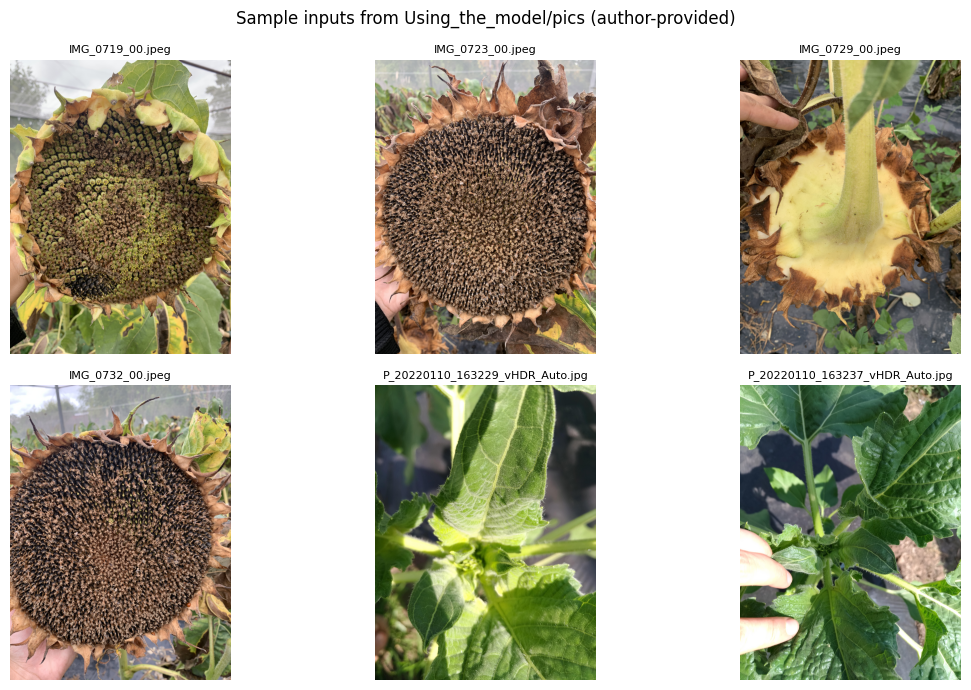

In [ ]:
import matplotlib.pyplot as plt
show = [f for f in imgs if f.lower().endswith((".jpg", ".jpeg"))][:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, f in zip(axes.ravel(), show):
    ax.imshow(Image.open(os.path.join("sample_pics", f)))
    ax.set_title(f, fontsize=8)
    ax.axis("off")
plt.suptitle("Sample inputs from Using_the_model/pics (author-provided)")
plt.tight_layout(); plt.show()

## 8. Inference on all sample images (authors' exact inference path)

This reproduces `test_images.py` on the `pics` sample: for each image apply `Resize((224,224))` and `ToTensor()` (**no** ImageNet normalization — that is the authors' transform), run the model under `torch.no_grad()`, apply `softmax(dim=1)`, and take `argmax+1` as stage S1..S5 with the softmax confidence.

Expected result: a table of 35 rows (filename, predicted stage, confidence), a few seconds total.

In [ ]:
import torchvision.transforms as transforms
import pandas as pd
from tqdm.auto import tqdm

TRANSFORMS_INFERENCE = transforms.Compose(
    [transforms.Resize((224, 224)), transforms.ToTensor()]
)
rows = []
with torch.no_grad():
    for name in tqdm(imgs):
        if not name.lower().endswith((".jpg", ".jpeg")):
            continue
        img = Image.open(os.path.join("sample_pics", name)).convert("RGB")
        x = TRANSFORMS_INFERENCE(img).unsqueeze(0).to(DEVICE)
        preds = model(x)
        preds = torch.softmax(preds, dim=1)
        idx = preds.argmax(dim=1)
        rows.append({
            "image": name,
            "predicted_stage": f"S{idx.item()+1}",
            "confidence": round(preds[0, idx.item()].item(), 4),
        })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

  0%|          | 0/34 [00:00<?, ?it/s]

                           image predicted_stage  confidence
                IMG_0719_00.jpeg              S5      0.8533
                IMG_0723_00.jpeg              S5      0.9672
                IMG_0729_00.jpeg              S5      0.9887
                IMG_0732_00.jpeg              S5      0.9820
 P_20220110_163229_vHDR_Auto.jpg              S1      0.8269
 P_20220110_163237_vHDR_Auto.jpg              S1      0.8171
 P_20220110_163356_vHDR_Auto.jpg              S1      0.8413
 P_20220110_163532_vHDR_Auto.jpg              S1      0.8759
 P_20220110_163558_vHDR_Auto.jpg              S1      0.9184
kP_20220110_163222_vHDR_Auto.jpg              S1      0.9024
kP_20220110_163537_vHDR_Auto.jpg              S1      0.9706
kP_20220110_163625_vHDR_Auto.jpg              S1      0.9242
kP_20220110_163707_vHDR_Auto.jpg              S1      0.9099
kP_20220110_164100_vHDR_Auto.jpg              S1      0.8522
kP_20220110_164829_vHDR_Auto.jpg              S1      0.9617
kP_20220110_164914_vHDR_

## 9. Result summary and export

We summarise the stage distribution of the sample set and save the predictions as CSV inside Colab. Note these images come from a few shoot dates of the case-study fields; the paper's Figure 8-style interpretation (stage progression over thermal time) needs the per-date experiment folders, which are beyond this minimal scope. No quantitative comparison against author reference values is possible for this sample set (the `results` CSVs in the shared Drive correspond to the exp2021/exp2022 case-study sets, not to `pics`).

**日本語:** サンプル集合のステージ分布をまとめ、CSVに保存します。このサンプルには著者の参照出力がないため、数値比較は行いません。

In [ ]:
dist = df["predicted_stage"].value_counts().sort_index()
print(dist.to_string())
csv_path = "sunpheno_predictions.csv"
df.to_csv(csv_path, index=False)
print("saved:", csv_path)

predicted_stage
S1    30
S5     4
saved: sunpheno_predictions.csv


## 10. Predicted stage overlaid on the input images

To make the output visually checkable we draw each prediction (stage + confidence) onto the corresponding input photo — the model output over the original author-provided image, clearly labelled as prediction. This is the visual record of this reproduction, not an author figure.

**日本語:** 予測ステージと信頼度を入力画像上に描画します（モデル予測の可視化であり、著者の図ではありません）。

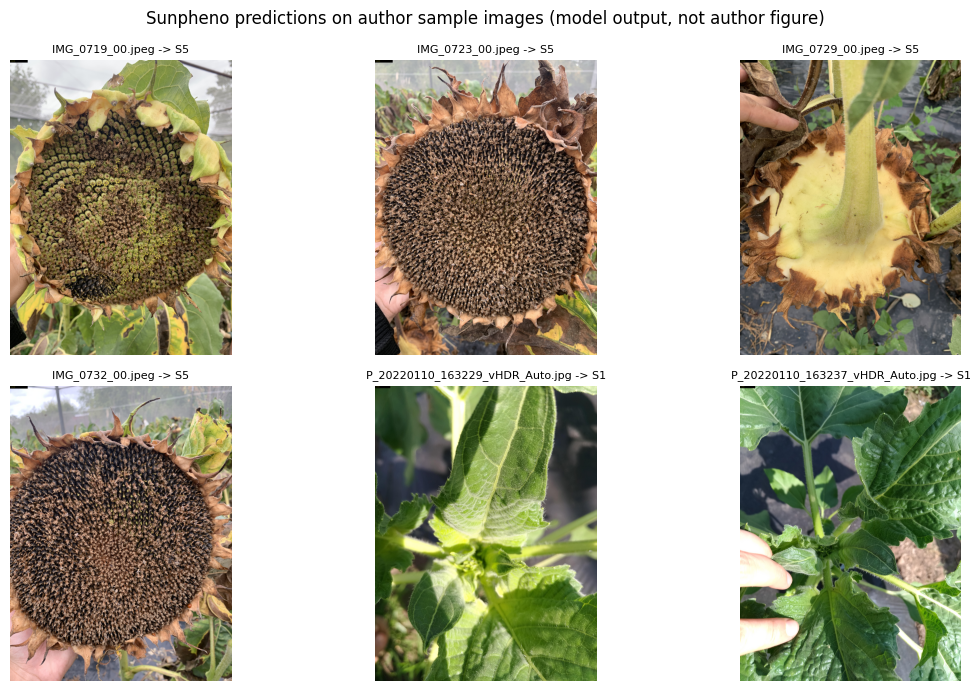

In [ ]:
from PIL import ImageDraw
annotated = []
for _, r in df.iterrows():
    im = Image.open(os.path.join("sample_pics", r["image"])).convert("RGB")
    d = ImageDraw.Draw(im)
    txt = f"{r['predicted_stage']}  conf={r['confidence']:.2f}"
    d.rectangle([0, 0, 240, 34], fill=(0, 0, 0))
    d.text((8, 8), txt, fill=(255, 255, 0))
    annotated.append(im)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (im, (_, r)) in zip(axes.ravel(), zip(annotated, df.iterrows())):
    ax.imshow(im); ax.set_title(f"{r['image']} -> {r['predicted_stage']}", fontsize=8); ax.axis("off")
plt.suptitle("Sunpheno predictions on author sample images (model output, not author figure)")
plt.tight_layout(); plt.savefig("sunpheno_predictions_grid.png", dpi=90, bbox_inches="tight"); plt.show()

## 11. Interpretation, differences from the paper, validation record

- **What was reproduced:** the authors' released inference path (`test_images.py` semantics) with their released ResNet50 checkpoint on 35 author-provided sample images: stages S1–S5 with softmax confidence, CPU.
- **Faithfulness notes:** transforms, class indexing (+1) and softmax follow the pinned code verbatim; the model class is copied unchanged. The authors ran on `cuda:1`; we run on CPU — mathematically equivalent for eval-mode inference, minor float differences possible.
- **Not reproduced / not verified:** training, the 95.7% test accuracy on the 450-image held-out set, and the exp2021/exp2022 case study; the full 5000-image database is available only on request from the authors.
- **Reference values:** none available for this sample set (see section 9); plausibility only — predictions cover stages of the sampled shoot dates and confidences are softmax values.
- **License:** no license file accompanies the shared code/weights; reuse terms are the authors'.
- **Validation:** this notebook was executed top-to-bottom in a fresh Colab CPU runtime on 2026-10-06; the archived executed notebook and CLI log are in the run's `logs/` directory.

**日本語:** 本ノートブックは公開推論経路の最小再現です。訓練・精度検証・ケーススタディは範囲外であり、サンプル集合に対する著者の参照出力はないため、数値比較は行っていません。